In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

   weight  Height
0      50     152
1      60     165
2      65     168
3      70     174
4      85     186


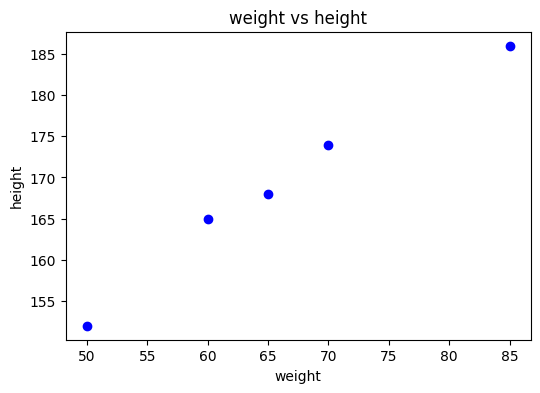

In [ ]:
data = pd.DataFrame({
    "weight":[50,60,65,70,85],
    "Height": [152,165,168,174,186]
 })

data.to_csv("weight_height.csv")
print(data)

x = data.iloc[:,0].values
y = data.iloc[:,1].values


plt.figure(figsize=(6,4))
plt.scatter(x,y, color='blue', marker='o')
plt.title('weight vs height')
plt.xlabel('weight')
plt.ylabel('height')
plt.show()


In [ ]:
def hypothesis(x,slope,yintercept):
    return x*slope + yintercept

def mse(y_pred, y_true):
    error = np.mean((y_pred - y_true)**2)
    return error

def compute_derivative(x, y_pred, y_true):
    n = len(x)
    ds= (1/n) * np.sum((y_pred - y_true)*x)
    db= (1/n) * np.sum(y_pred - y_true)
    return ds,db


def gradint_descent(x,y):
    s=1  # slope
    b=0  # y_intercept
    learn_rate = 0.0001
    errors = []
    epochs=1000

    for i in range(epochs):
        y_pred = hypothesis(x,s,b)
        error = mse(y_pred,y)
        errors.append(error)

        ds, db = compute_derivative(x, y_pred, y)

        s = s - learn_rate*(ds)
        b = b - learn_rate*(db)

        if i % 100 == 0:
            print(f'iteration: {i}, mse: {error:.4f}, slope: {s:.4f}, y-intersept: {b:.4f}')

    return s, b, errors


iteration: 0, mse: 10611.0000, slope: 1.6792, y-intersept: 0.0103
iteration: 100, mse: 336.4360, slope: 2.5119, y-intersept: 0.0542
iteration: 200, mse: 336.2363, slope: 2.5114, y-intersept: 0.0857
iteration: 300, mse: 336.0368, slope: 2.5110, y-intersept: 0.1173
iteration: 400, mse: 335.8373, slope: 2.5105, y-intersept: 0.1489
iteration: 500, mse: 335.6380, slope: 2.5101, y-intersept: 0.1805
iteration: 600, mse: 335.4388, slope: 2.5096, y-intersept: 0.2120
iteration: 700, mse: 335.2397, slope: 2.5091, y-intersept: 0.2436
iteration: 800, mse: 335.0408, slope: 2.5087, y-intersept: 0.2751
iteration: 900, mse: 334.8419, slope: 2.5082, y-intersept: 0.3066
MSE= 334.6432
slope= 2.5077 
y-intercept: 0.3378

Expected height for weight = 72 kg is approximately: 180.90 cm


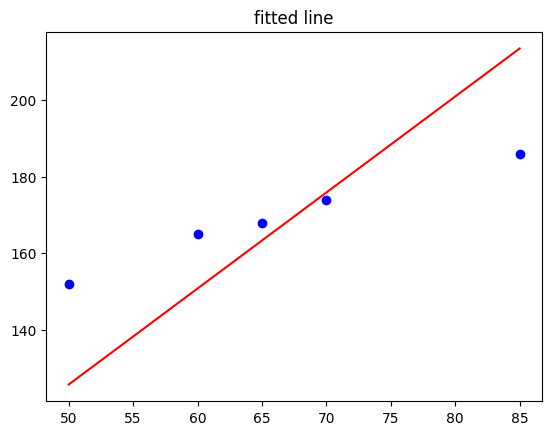

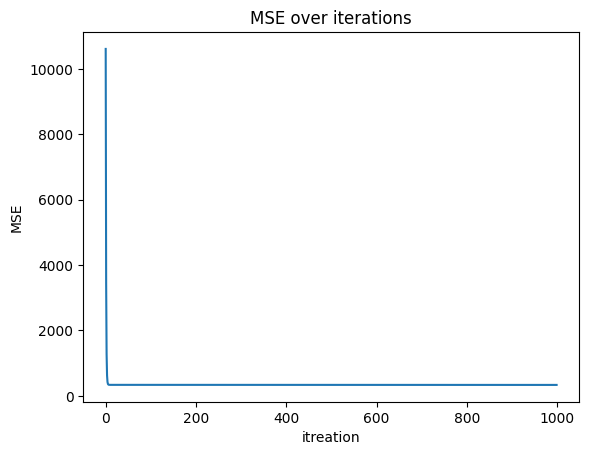

In [ ]:
s, b, errors = gradint_descent(x,y)

# Evaluation
y_pred = hypothesis(x,s,b)
acc = mse(y_pred, y)

print(f'MSE= {acc:.4f}\nslope= {s:.4f} \ny-intercept: {b:.4f}')

predicted_height = hypothesis(72, s, b)
print(f"\nExpected height for weight = 72 kg is approximately: {predicted_height:.2f} cm")

plt.scatter(x,y, color='blue')
plt.plot(x,y_pred, color='red')
plt.title('fitted line')
plt.show()

plt.plot(range(len(errors)), errors)
plt.title("MSE over iterations")
plt.xlabel("itreation")
plt.ylabel("MSE")
plt.show()